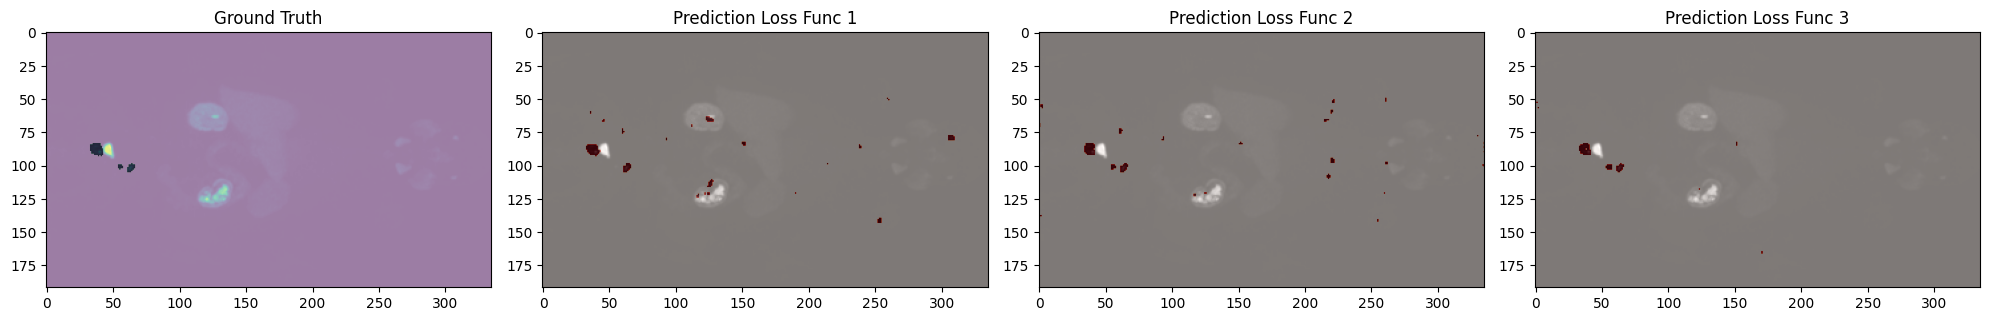

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import nibabel as nib
from glob import glob

# Function to read the nii volumes
def read_nii_vol(target_filename):
    img = nib.load(target_filename)
    VOL = np.array(img.dataobj)
    return VOL

ptpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/imagesTr/PSMA-01-159_0001.nii.gz"
gtpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/labelsTr/PSMA-01-159.nii.gz"
pred_paths = [
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/validation_predictions/\
attunet/fold1/diceloss/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-159.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/validation_predictions/\
attunet/fold1/dicefocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-159.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/validation_predictions/\
attunet/fold1/L1ghdl/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-159.nii.gz"
]

# Read the PET volume and the ground truth mask
PET_VOL = read_nii_vol(ptpath)
MASK_VOL = read_nii_vol(gtpath)

# Read predictions for each loss function
MASK_PRED_VOLS = [read_nii_vol(pred_path) for pred_path in pred_paths]

# Create Coronal MIP for the PET image and masks
PET_MIP_C = np.max(PET_VOL, axis=1)
PET_MIP_C = cv2.normalize(PET_MIP_C, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

MASK_MIP_C = np.max(MASK_VOL, axis=1)
MASK_MIP_C = np.uint8(MASK_MIP_C)

# Generate Coronal MIPs for the predicted masks
MASK_PRED_MIPS = [np.max(pred_vol, axis=1) for pred_vol in MASK_PRED_VOLS]

# Plotting
fig, axes = plt.subplots(1, 4, figsize=(20, 16))

# Plot the ground truth mask
axes[0].imshow(PET_MIP_C)
MASK_OVERLAY = np.zeros_like(PET_MIP_C)
MASK_OVERLAY[MASK_MIP_C > 0] = 1  # Mark lesion regions as 1
axes[0].imshow(MASK_OVERLAY, cmap='Greens', alpha=0.5)  # Green for ground truth
axes[0].set_title('Ground Truth')

# Plot the predictions from the three different loss functions
for idx, mask_pred_mip in enumerate(MASK_PRED_MIPS):
    axes[idx+1].imshow(PET_MIP_C, cmap='gray')
    PRED_OVERLAY = np.zeros_like(PET_MIP_C)
    PRED_OVERLAY[mask_pred_mip > 0] = 1  # Mark predicted regions as 1
    axes[idx+1].imshow(PRED_OVERLAY, cmap='Reds', alpha=0.5)  # Red for predictions
    axes[idx+1].set_title(f'Prediction Loss Func {idx+1}')

plt.tight_layout()
plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

ptpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/imagesTr/PSMA-01-159_0001.nii.gz"
gtpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/labelsTr/PSMA-01-159.nii.gz"
pred_paths = [
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/validation_predictions/\
attunet/fold1/diceloss/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-159.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/validation_predictions/\
attunet/fold1/dicefocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-159.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/validation_predictions/\
attunet/fold1/L1ghdl/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-159.nii.gz"
]


# Function to read nii volumes
def read_nii_vol(target_filename):
    img = nib.load(target_filename)
    VOL = np.array(img.dataobj)
    return VOL

for i in range(len(pred_paths)):
    PET_Full_filename = ptpath
    MASK_Full_filename = gtpath
    MASK_PRED_filename = pred_paths

    PET_VOL = read_nii_vol(PET_Full_filename)
    PET_VOL = np.float64(PET_VOL)

    MASK_VOL = read_nii_vol(MASK_Full_filename)
    MASK_VOL = np.uint8(MASK_VOL)

    # Predicted
    MASK_PRED_VOL = read_nii_vol(MASK_PRED_filename)
    MASK_PRED_VOL = np.uint8(MASK_PRED_VOL)

    # Create Coronal MIP for the PET image and masks
    PET_MIP_C = np.max(PET_VOL, axis=1)
    PET_MIP_C = cv2.normalize(PET_MIP_C, None, 0, 255, cv2.NORM_MINMAX)
    PET_MIP_C = PET_MIP_C.astype(np.uint8)
    PET_MIP_C = cv2.cvtColor(PET_MIP_C, cv2.COLOR_GRAY2BGR)  # Color conversion for PET

    MASK_MIP_C = np.max(MASK_VOL, axis=1)  # Ground truth mask (coronal)
    MASK_PRED_MIP_C = np.max(MASK_PRED_VOL, axis=1)  # Predicted mask (coronal)

    # Normalize predicted mask and ground truth for overlay
    MASK_MIP_C = np.uint8(MASK_MIP_C * 255)
    MASK_PRED_MIP_C = np.uint8(MASK_PRED_MIP_C * 255)

    # Colorize the ground truth in green and the predictions in red
    PET_OVERLAY_GT = PET_MIP_C.copy()
    PET_OVERLAY_PRED = PET_MIP_C.copy()

    # Ground truth overlay (green)
    PET_OVERLAY_GT[MASK_MIP_C > 0] = [0, 255, 0]  # Green where the mask is positive (GT)

    # Prediction overlay (red)
    PET_OVERLAY_PRED[MASK_PRED_MIP_C > 0] = [255, 0, 0]  # Red where the prediction mask is positive

    # Blend the PET background with the ground truth and predicted overlays
    blend_factor = 0.6
    PET_OVERLAY_FINAL = cv2.addWeighted(PET_MIP_C, 1 - blend_factor, PET_OVERLAY_GT, blend_factor, 0)
    PET_OVERLAY_FINAL = cv2.addWeighted(PET_OVERLAY_FINAL, 1 - blend_factor, PET_OVERLAY_PRED, blend_factor, 0)

    # Create Sagittal MIP for PET and masks
    PET_MIP_S = np.max(PET_VOL, axis=0)
    PET_MIP_S = cv2.normalize(PET_MIP_S, None, 0, 255, cv2.NORM_MINMAX)
    PET_MIP_S = PET_MIP_S.astype(np.uint8)
    PET_MIP_S = cv2.cvtColor(PET_MIP_S, cv2.COLOR_GRAY2BGR)  # Color conversion for PET

    MASK_MIP_S = np.max(MASK_VOL, axis=0)  # Ground truth mask (sagittal)
    MASK_PRED_MIP_S = np.max(MASK_PRED_VOL, axis=0)  # Predicted mask (sagittal)

    # Normalize predicted mask and ground truth for overlay
    MASK_MIP_S = np.uint8(MASK_MIP_S * 255)
    MASK_PRED_MIP_S = np.uint8(MASK_PRED_MIP_S * 255)

    # Colorize the ground truth in green and the predictions in red
    PET_OVERLAY_GT_S = PET_MIP_S.copy()
    PET_OVERLAY_PRED_S = PET_MIP_S.copy()

    # Ground truth overlay (green)
    PET_OVERLAY_GT_S[MASK_MIP_S > 0] = [0, 255, 0]  # Green where the mask is positive (GT)

    # Prediction overlay (red)
    PET_OVERLAY_PRED_S[MASK_PRED_MIP_S > 0] = [255, 0, 0]  # Red where the prediction mask is positive

    # Blend the PET background with the ground truth and predicted overlays
    PET_OVERLAY_FINAL_S = cv2.addWeighted(PET_MIP_S, 1 - blend_factor, PET_OVERLAY_GT_S, blend_factor, 0)
    PET_OVERLAY_FINAL_S = cv2.addWeighted(PET_OVERLAY_FINAL_S, 1 - blend_factor, PET_OVERLAY_PRED_S, blend_factor, 0)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(12, 12))

    im1 = axes[0].imshow(np.rot90(PET_OVERLAY_FINAL))
    axes[0].set_title('PET Coronal view with Overlays')

    im2 = axes[1].imshow(np.rot90(PET_OVERLAY_FINAL_S))
    axes[1].set_title('PET Sagittal view with Overlays')

    plt.tight_layout()
    # save_path = os.path.join(save_fig_path, f"{_files[i]}.png")
    # fig.savefig(save_path)
    fig.clear()
    plt.close()


TypeError: stat: path should be string, bytes, os.PathLike or integer, not list

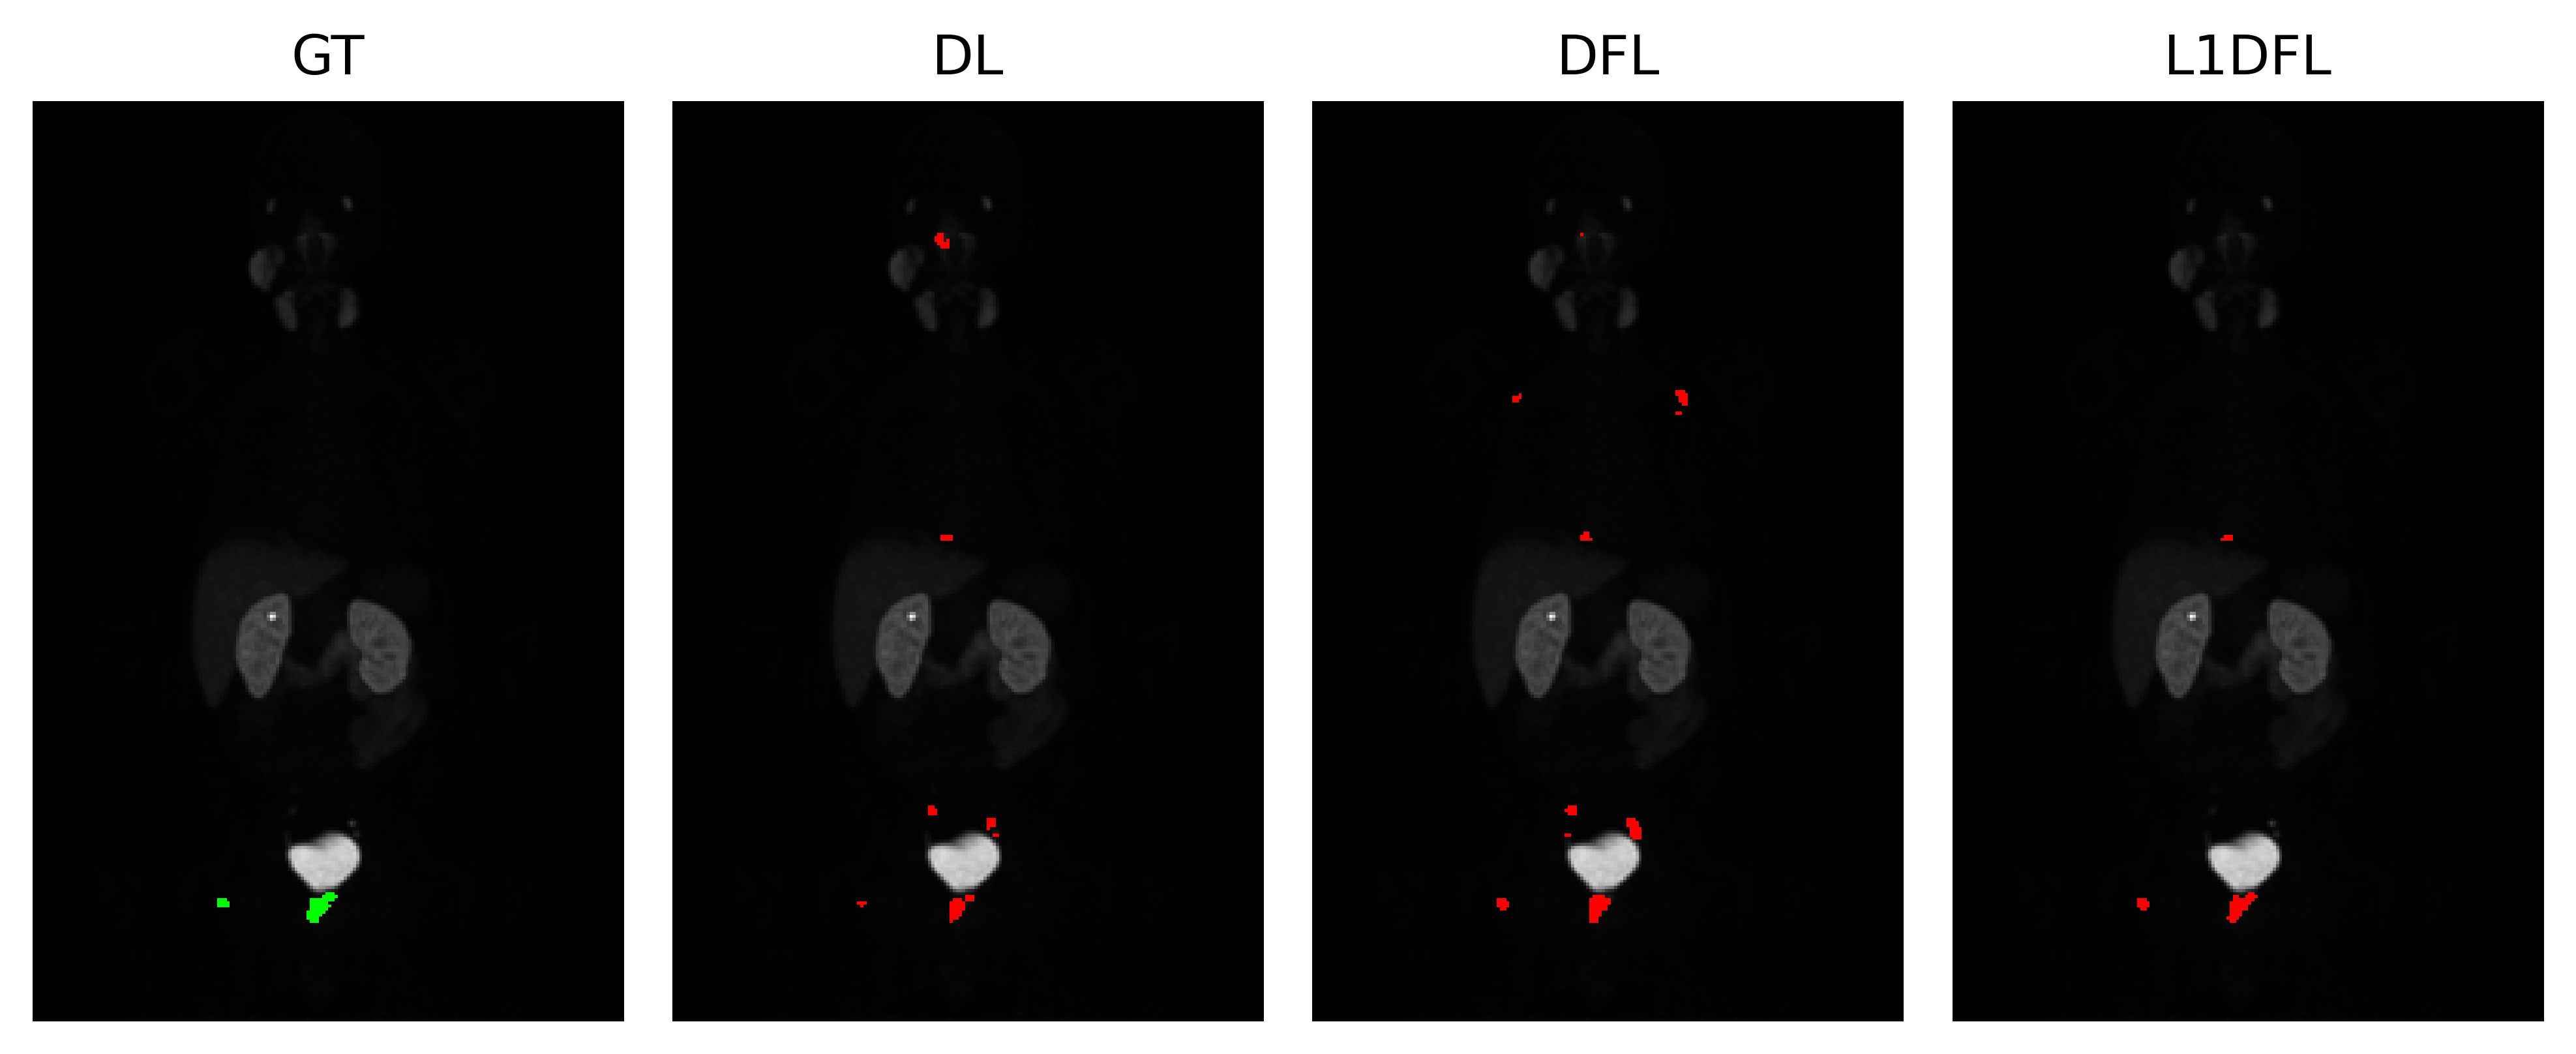

In [2]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Function to read NIfTI files
def read_nii_vol(target_filename):
    img = nib.load(target_filename)
    VOL = np.array(img.dataobj)
    return VOL

# File paths provided
ptpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/imagesTs/PSMA-01-001_0001.nii.gz"
gtpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/labelsTs/PSMA-01-001.nii.gz"
pred_paths = [
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/diceloss/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-001.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/dicefocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-001.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/L1ghdlfocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-001.nii.gz"
]

# Read PET, ground truth, and prediction volumes
PET_VOL = read_nii_vol(ptpath)
MASK_VOL = read_nii_vol(gtpath)
PRED_VOLS = [read_nii_vol(pred_path) for pred_path in pred_paths]

# Generate Coronal Maximum Intensity Projections (MIP) for PET, Ground Truth, and Predictions
PET_MIP_C = np.max(PET_VOL, axis=1)
PET_MIP_C = cv2.normalize(PET_MIP_C, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
PET_MIP_C = cv2.cvtColor(PET_MIP_C, cv2.COLOR_GRAY2BGR)

MASK_MIP_C = np.max(MASK_VOL, axis=1)
MASK_MIP_C = cv2.cvtColor((MASK_MIP_C * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR)

PRED_MIPS_C = [np.max(pred_vol, axis=1) for pred_vol in PRED_VOLS]
PRED_MIPS_C = [cv2.cvtColor((pred_mip * 255).astype(np.uint8), cv2.COLOR_GRAY2BGR) for pred_mip in PRED_MIPS_C]

# Plot the ground truth and predictions for the loss functions
fig, axes = plt.subplots(1, 4, figsize=(8, 8), dpi=500)
plt.subplots_adjust(wspace=0.01)

# Ground truth mask in green
MASK_COLOR = np.copy(PET_MIP_C)
MASK_COLOR[MASK_MIP_C[:, :, 0] > 0] = [0, 255, 0]  # Green for ground truth
axes[0].imshow(np.rot90(MASK_COLOR))
axes[0].set_title('GT',fontsize=12)

# Predictions for different loss functions in red
for idx, pred_mip in enumerate(PRED_MIPS_C):
    PRED_COLOR = np.copy(PET_MIP_C)
    PRED_COLOR[pred_mip[:, :, 0] > 0] = [255, 0, 0]  # Red for predicted lesions
    axes[idx + 1].imshow(np.rot90(PRED_COLOR))
    if idx==0:
        axes[idx + 1].set_title(f'DL', fontsize=12)
    elif idx==1:
        axes[idx + 1].set_title(f'DFL', fontsize=12)
    elif idx==2:
        axes[idx + 1].set_title(f'L1DFL', fontsize=12)

# Remove axis labels for cleaner visualization
for ax in axes:
    ax.axis('off')
    
save_path = os.path.join("/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/single_fold_results/segresnet/fold1model", "seg_results.png")
plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()


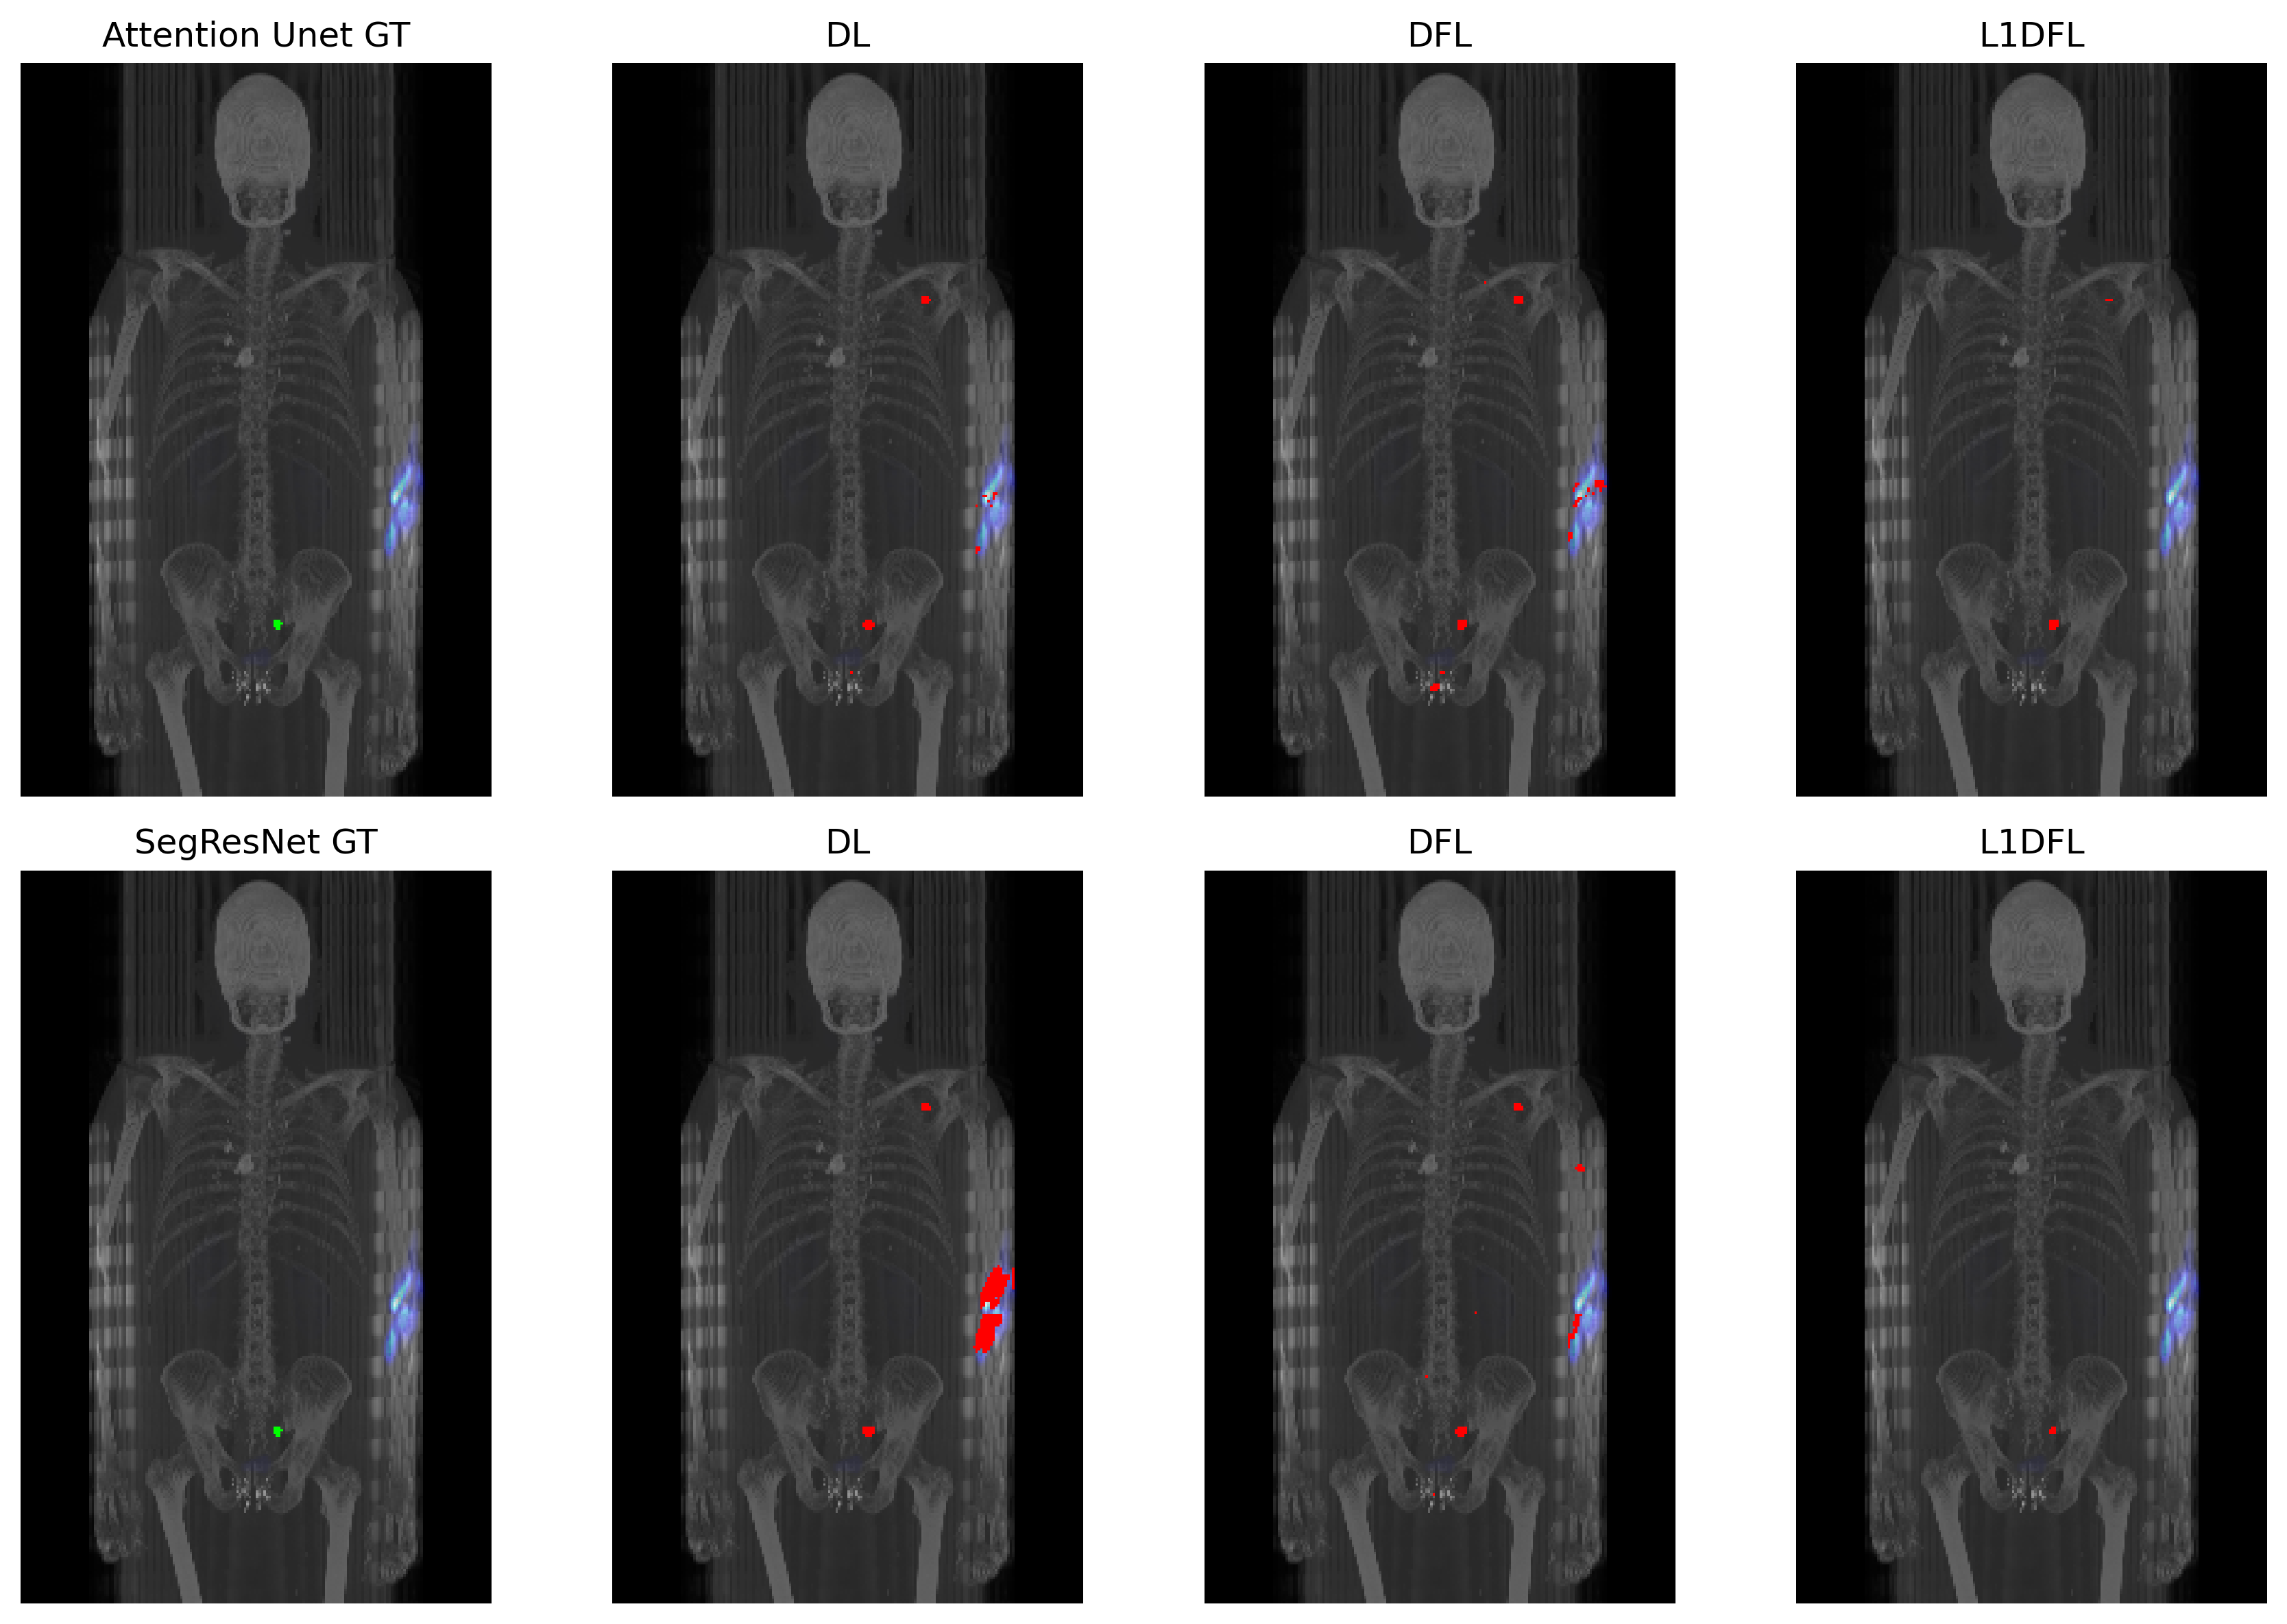

In [5]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Function to read NIfTI files
def read_nii_vol(target_filename):
    img = nib.load(target_filename)
    VOL = np.array(img.dataobj)
    return VOL

# File paths provided
ctpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/imagesTs/PSMA-01-253_0000.nii.gz"
ptpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/imagesTs/PSMA-01-253_0001.nii.gz"
gtpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/labelsTs/PSMA-01-253.nii.gz"

# Prediction paths for both networks
# Prediction paths for both networks
pred_paths_segresnet = [
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/diceloss/predictions/fold1/segresnet/segresnet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/dicefocal/predictions/fold1/segresnet/segresnet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/L1ghdlfocal/predictions/fold1/segresnet/segresnet_fold1_randcrop128/PSMA-01-253.nii.gz"
]

pred_paths_attunet = [
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
attunet_preds/diceloss/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
attunet_preds/dicefocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
attunet_preds/L1ghdlfocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-253.nii.gz"
]


# Read PET, CT, ground truth, and prediction volumes
PET_VOL = read_nii_vol(ptpath)
CT_VOL = read_nii_vol(ctpath)
MASK_VOL = read_nii_vol(gtpath)
PRED_VOLS_SEGRESNET = [read_nii_vol(pred_path) for pred_path in pred_paths_segresnet]
PRED_VOLS_ATTUNET = [read_nii_vol(pred_path) for pred_path in pred_paths_attunet]

# Generate Coronal Maximum Intensity Projections (MIP) for PET, CT, Ground Truth, and Predictions
PET_MIP_C = np.max(PET_VOL, axis=1)
CT_MIP_C = np.max(CT_VOL, axis=1)

# Normalize PET and CT MIPs
PET_MIP_C = cv2.normalize(PET_MIP_C, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
CT_MIP_C = cv2.normalize(CT_MIP_C, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert CT MIP to 3 channels for colorization
CT_MIP_C = cv2.cvtColor(CT_MIP_C, cv2.COLOR_GRAY2BGR)

# Overlay PET on CT
ALPHA = 0.6  # Weight for CT
BETA = 0.4   # Weight for PET
PET_CT_OVERLAY = cv2.addWeighted(CT_MIP_C, ALPHA, cv2.applyColorMap(PET_MIP_C, cv2.COLORMAP_HOT), BETA, 0)

# Generate mask MIP for ground truth and convert it to color
MASK_MIP_C = np.max(MASK_VOL, axis=1)

PRED_MIPS_SEGRESNET_C = [np.max(pred_vol, axis=1) for pred_vol in PRED_VOLS_SEGRESNET]
PRED_MIPS_ATTUNET_C = [np.max(pred_vol, axis=1) for pred_vol in PRED_VOLS_ATTUNET]

# Plot the ground truth and predictions for the loss functions
fig, axes = plt.subplots(2, 4, figsize=(12, 8), dpi=300)  # 2 rows for networks, 4 columns (GT + 3 loss functions)
plt.subplots_adjust(wspace=0.01, hspace=0.01)

# Function to colorize predictions and display
def plot_row(axes_row, pred_mips, network_name):
    # Ground truth mask in green
    MASK_COLOR = np.copy(PET_CT_OVERLAY)
    MASK_COLOR[MASK_MIP_C > 0] = [0, 255, 0]  # Green for ground truth
    axes_row[0].imshow(np.rot90(MASK_COLOR))
    axes_row[0].set_title(f'GT', fontsize=12)
    
    # Predictions for different loss functions in red
    for idx, pred_mip in enumerate(pred_mips):
        PRED_COLOR = np.copy(PET_CT_OVERLAY)
        PRED_COLOR[pred_mip > 0] = [255, 0, 0]  # Red for predicted lesions
        axes_row[idx + 1].imshow(np.rot90(PRED_COLOR))
        if idx == 0:
            axes_row[idx + 1].set_title('DL', fontsize=12)
        elif idx == 1:
            axes_row[idx + 1].set_title('DFL', fontsize=12)
        elif idx == 2:
            axes_row[idx + 1].set_title('L1DFL', fontsize=12)

# Plot for Attention Unet
plot_row(axes[0], PRED_MIPS_ATTUNET_C, "Attention Unet")

# Plot for SegResNet
plot_row(axes[1], PRED_MIPS_SEGRESNET_C, "SegResNet")

# Remove axis labels for cleaner visualization
for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

save_path = os.path.join("/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/single_fold_results/", "seg_results.png")
# plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()



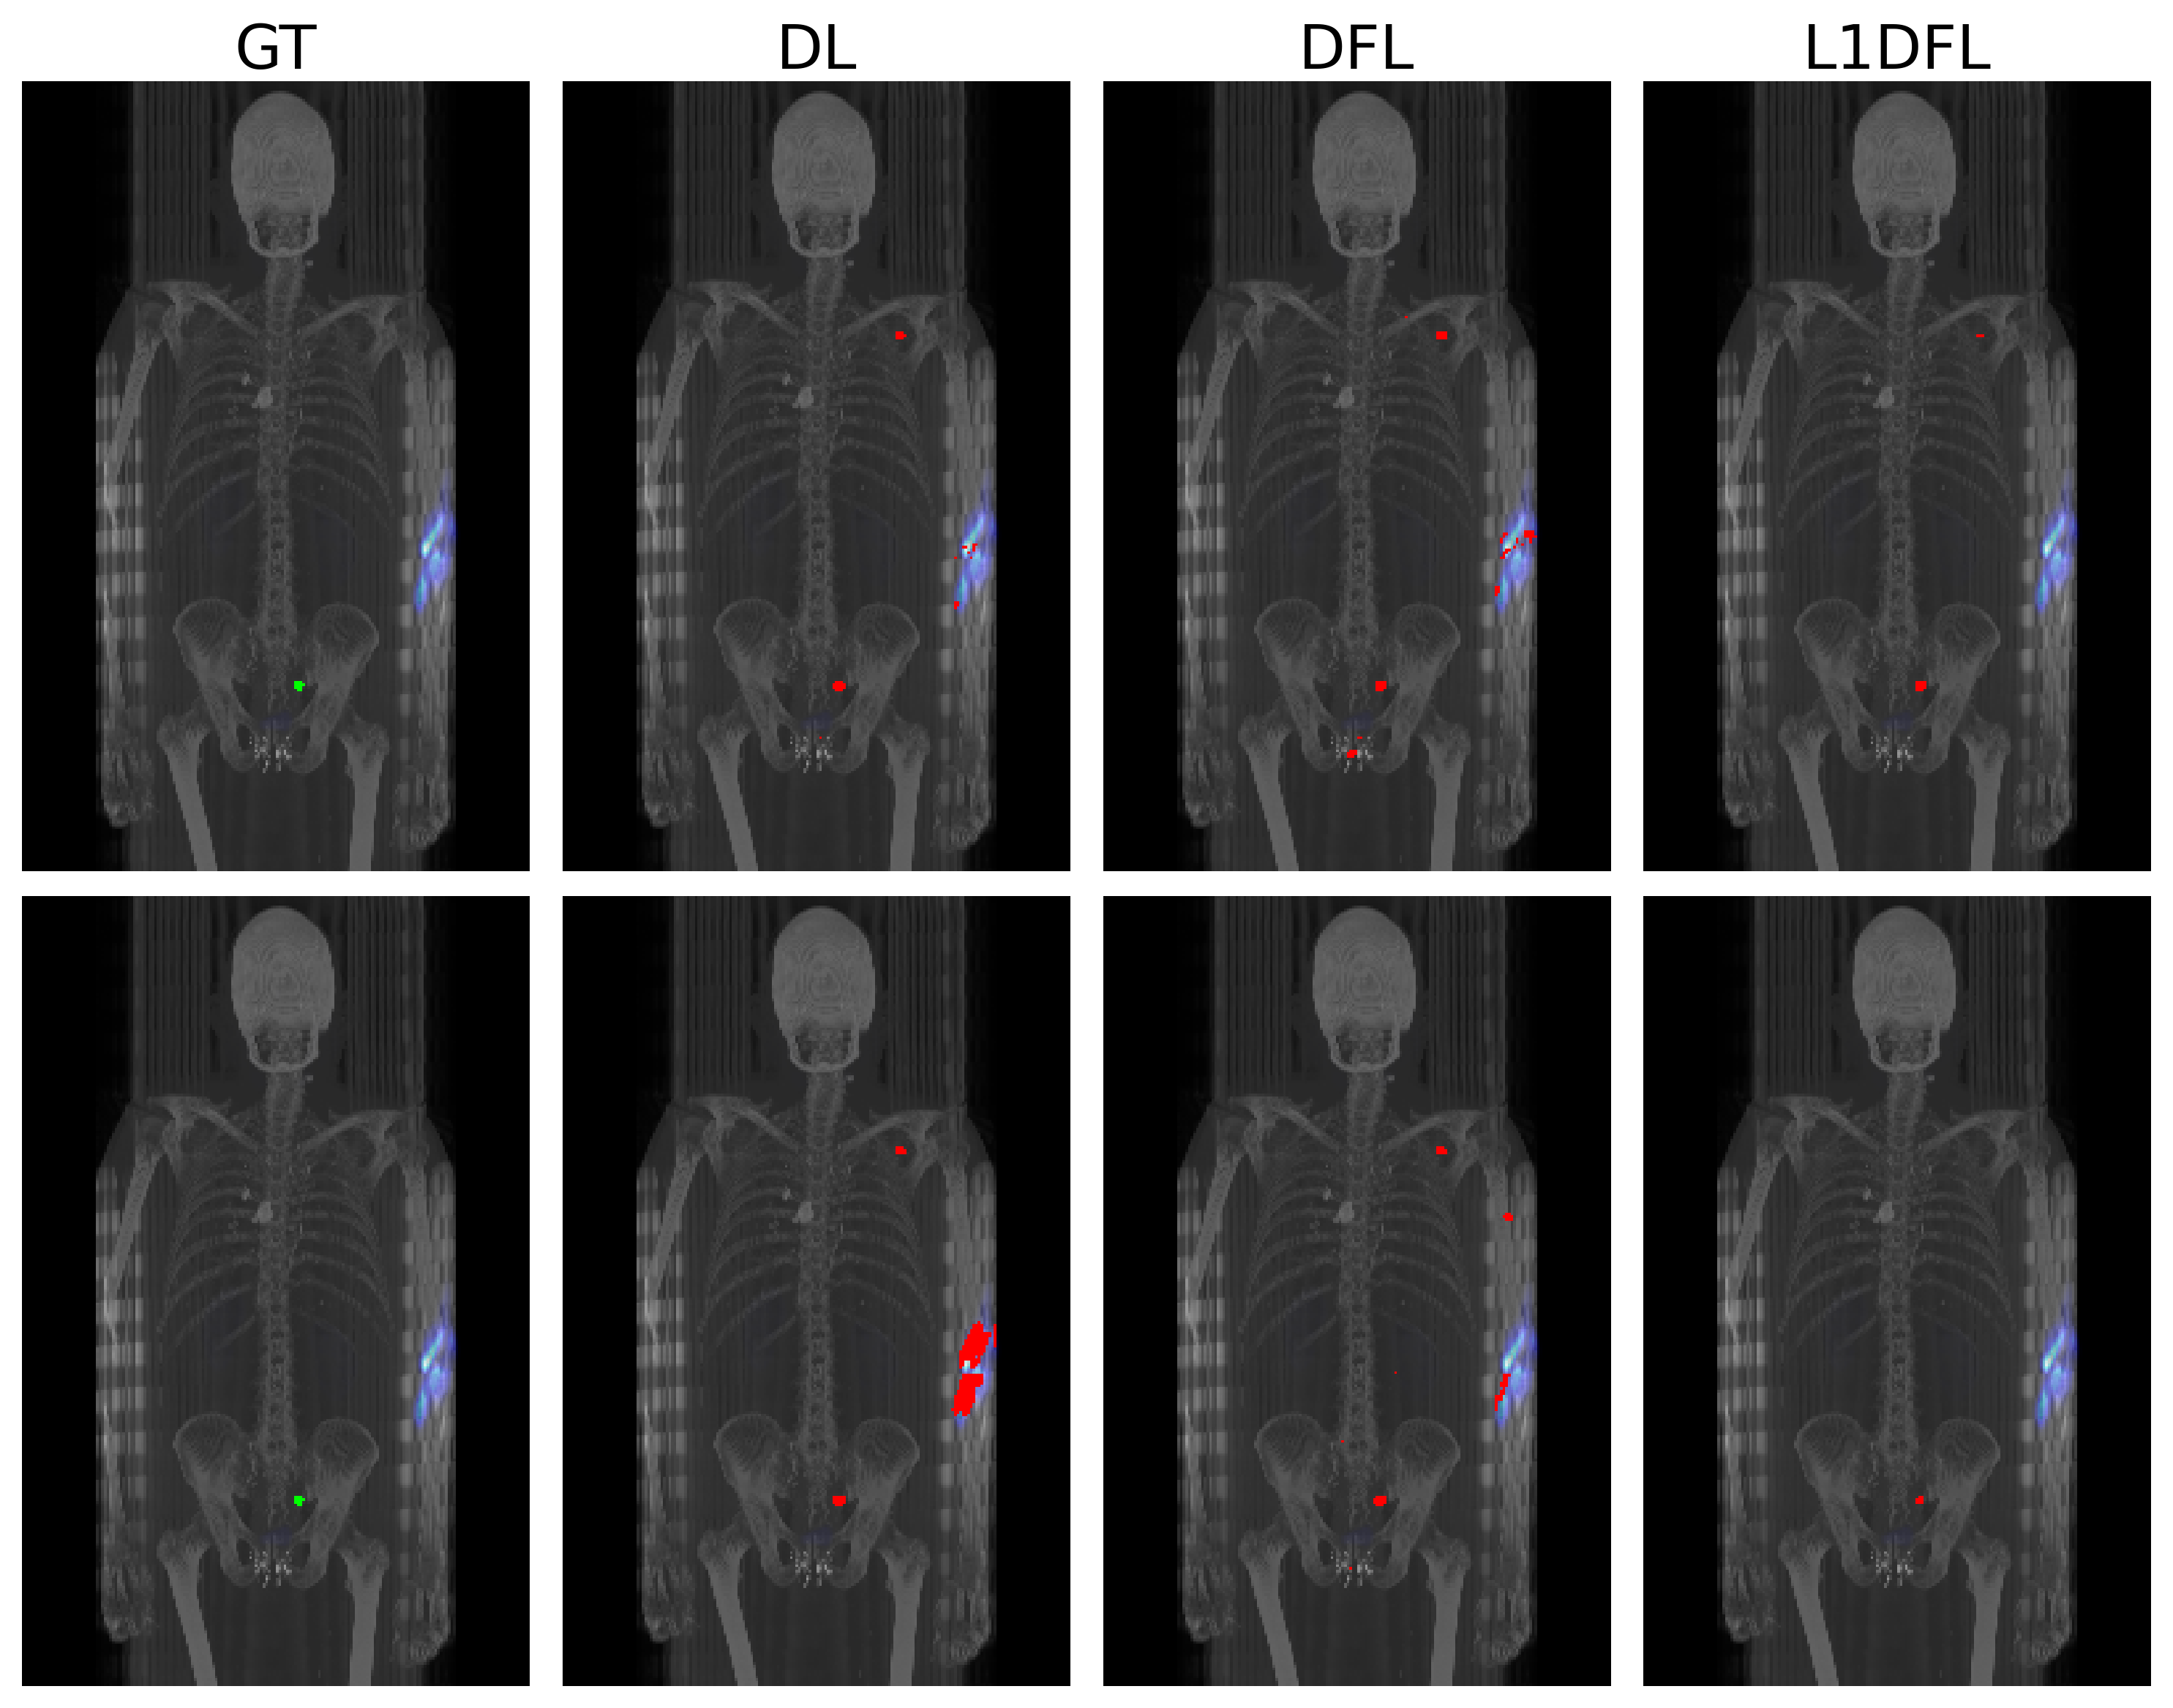

In [44]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Function to read NIfTI files
def read_nii_vol(target_filename):
    img = nib.load(target_filename)
    VOL = np.array(img.dataobj)
    return VOL

# File paths provided
ctpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/imagesTs/PSMA-01-253_0000.nii.gz"
ptpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/imagesTs/PSMA-01-253_0001.nii.gz"
gtpath = "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/data/labelsTs/PSMA-01-253.nii.gz"

# Prediction paths for both networks
# Prediction paths for both networks
pred_paths_segresnet = [
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/diceloss/predictions/fold1/segresnet/segresnet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/dicefocal/predictions/fold1/segresnet/segresnet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
segresnet_preds/L1ghdlfocal/predictions/fold1/segresnet/segresnet_fold1_randcrop128/PSMA-01-253.nii.gz"
]

pred_paths_attunet = [
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
attunet_preds/diceloss/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
attunet_preds/dicefocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-253.nii.gz",
    "/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/test_predictions/\
attunet_preds/L1ghdlfocal/predictions/fold1/attunet/attunet_fold1_randcrop128/PSMA-01-253.nii.gz"
]

# Read PET, CT, ground truth, and prediction volumes
PET_VOL = read_nii_vol(ptpath)
CT_VOL = read_nii_vol(ctpath)
MASK_VOL = read_nii_vol(gtpath)
PRED_VOLS_SEGRESNET = [read_nii_vol(pred_path) for pred_path in pred_paths_segresnet]
PRED_VOLS_ATTUNET = [read_nii_vol(pred_path) for pred_path in pred_paths_attunet]

# Generate Coronal Maximum Intensity Projections (MIP) for PET, CT, Ground Truth, and Predictions
PET_MIP_C = np.max(PET_VOL, axis=1)
CT_MIP_C = np.max(CT_VOL, axis=1)

# Normalize PET and CT MIPs
PET_MIP_C = cv2.normalize(PET_MIP_C, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
CT_MIP_C = cv2.normalize(CT_MIP_C, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Convert CT MIP to 3 channels for colorization
CT_MIP_C = cv2.cvtColor(CT_MIP_C, cv2.COLOR_GRAY2BGR)

# Overlay PET on CT
ALPHA = 0.6  # Weight for CT
BETA = 0.4   # Weight for PET
PET_CT_OVERLAY = cv2.addWeighted(CT_MIP_C, ALPHA, cv2.applyColorMap(PET_MIP_C, cv2.COLORMAP_HOT), BETA, 0)

# Generate mask MIP for ground truth and convert it to color
MASK_MIP_C = np.max(MASK_VOL, axis=1)

PRED_MIPS_SEGRESNET_C = [np.max(pred_vol, axis=1) for pred_vol in PRED_VOLS_SEGRESNET]
PRED_MIPS_ATTUNET_C = [np.max(pred_vol, axis=1) for pred_vol in PRED_VOLS_ATTUNET]

# Plot the ground truth and predictions for the loss functions
fig, axes = plt.subplots(2, 4, figsize=(10, 8), dpi=300)  # 2 rows for networks, 4 columns (GT + 3 loss functions)
plt.subplots_adjust(wspace=0.2, hspace=0.1)

# Function to colorize predictions and display
def plot_row(axes_row, pred_mips, network_name):
    # Ground truth mask in green
    MASK_COLOR = np.copy(PET_CT_OVERLAY)
    MASK_COLOR[MASK_MIP_C > 0] = [0, 255, 0]  # Green for ground truth
    axes_row[0].imshow(np.rot90(MASK_COLOR))
    
    # Predictions for different loss functions in red
    for idx, pred_mip in enumerate(pred_mips):
        PRED_COLOR = np.copy(PET_CT_OVERLAY)
        PRED_COLOR[pred_mip > 0] = [255, 0, 0]  # Red for predicted lesions
        axes_row[idx + 1].imshow(np.rot90(PRED_COLOR))

# Plot for Attention Unet
plot_row(axes[0], PRED_MIPS_ATTUNET_C, "Attention Unet")

# Plot for SegResNet
plot_row(axes[1], PRED_MIPS_SEGRESNET_C, "SegResNet")

# Add titles to the first row to indicate columns (GT, DL, DFL, L1DFL)
column_titles = ['GT', 'DL', 'DFL', 'L1DFL']
for idx, col_title in enumerate(column_titles):
    axes[0, idx].set_title(col_title, fontsize=20, pad=0)  # Set pad for spacing

# Add network names as upper-center titles for each row
# fig.suptitle('Segmentation Results for Attention Unet (Top) and SegResNet (Bottom)', fontsize=16, y=0.95)

# Remove axis labels for cleaner visualization
for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

save_path = os.path.join("/data/blobfuse/PSMA_PCA_LESIONS_SEGMENTATION/data_resampled_results/single_fold_results/segresnet/fold1model", "seg_results.png")
plt.savefig(save_path, dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()
